<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorio_calificado_2_v3.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Calificado N° 2
**Curso**: MCD8012 - Visión Computacional

**Universidad**: UTEC

**Profesor**: Itamar Salazar

**Integrantes**:
- David Jimenez
- José Carlos Nomberto

## Ejercicio 1: Clasificador usando Regresión Logística

### Descripción

Entrenar un modelo de regresión logística para clasificar imágenes entre 3 tipos de
clases. Para ello escoja 3 clases entre las 10 que ofrece el dataset de CIFAR-10.

In [ ]:
# Importar librerías de python

In [ ]:
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


### Tarea 1 - Carga de Datos y Selección de Clases

Cargar del dataset CIFAR-10 y extraer solo 3 clases para el entrenamiento (use
cifar10.load_data() y use los valores por defecto que devuelve)

In [ ]:
# Cargar datos
print(f'\nCargado de Datos')
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f'\nTamaño de Dataset Completo')
print(f' - Tamaño de x_train: {x_train.shape}')
print(f' - Tamaño de x_test: {x_test.shape}')
print(f' - Tamaño de y_train: {y_train.shape}')
print(f' - Tamaño de y_test: {y_test.shape}')


Cargado de Datos
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Tamaño de Dataset Completo
 - Tamaño de x_train: (50000, 32, 32, 3)
 - Tamaño de x_test: (10000, 32, 32, 3)
 - Tamaño de y_train: (50000, 1)
 - Tamaño de y_test: (10000, 1)


In [ ]:
# Aplanar las etiquetas (vienen como matrices de 1 columna)
y_train = y_train.flatten()
y_test = y_test.flatten()

In [ ]:
# Nombres originales de las clases en CIFAR-10 para referencia
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Clases seleccionadas: 3 (cat), 5 (dog), 8 (ship)
class1_id = 3
class2_id = 5
class3_id = 8
selected_classes = [class1_id, class2_id, class3_id]
class_mapping = {original: new for new, original in enumerate(selected_classes)}
print(f'Clase 1 (3): {class_names[class1_id]}')
print(f'Clase 2 (5): {class_names[class2_id]}')
print(f'Clase 3 (8): {class_names[class3_id]}')

# Crear máscaras para filtrar los datos
train_mask = np.isin(y_train, selected_classes)
test_mask = np.isin(y_test, selected_classes)

# Filtrar imágenes
x_train_bin = x_train[train_mask]
y_train_bin = y_train[train_mask]
x_test_bin = x_test[test_mask]
y_test_bin = y_test[test_mask]

Clase 1 (3): cat
Clase 2 (5): dog
Clase 3 (8): ship


In [ ]:
# Re-mapeo de etiquetas para las clases seleccionadas
y_train_bin = np.array([class_mapping[label] for label in y_train_bin])
y_test_bin = np.array([class_mapping[label] for label in y_test_bin])

# Mostrar tamaños Dataset filtrado y re-mapeado
print(f'\nTamaño de Dataset Filtrado y Re-mapeado')
print(f' - Tamaño de x_train_bin: {x_train_bin.shape}')
print(f' - Tamaño de x_test_bin: {x_test_bin.shape}')
print(f' - Tamaño de y_train_bin: {y_train_bin.shape}')
print(f' - Tamaño de y_test_bin: {y_test_bin.shape}')


Tamaño de Dataset Filtrado y Re-mapeado
 - Tamaño de x_train_bin: (15000, 32, 32, 3)
 - Tamaño de x_test_bin: (3000, 32, 32, 3)
 - Tamaño de y_train_bin: (15000,)
 - Tamaño de y_test_bin: (3000,)


### Tarea 2 - Función de Extracción de Características

Crear una función que extraiga 8 características de cada imagen (en este caso
usaremos los canales R,G,B,H,S,V, bordes horizontales de sobel y bordes
verticales de sobel )

In [ ]:
def extract_features(image: np.ndarray, sobel_ksize: int = 3):
    """
    Extrae un vector de características de una imagen RGB de 32x32:

    - RGB original (3 canales)
    - HSV (3 canales)
    - Sobel horizontal y vertical sobre la escala de grises (2 canales)

    Devuelve un vector 1D de longitud 8*32*32 (8 canales x 32 width x 32 height)
    """
    # Normalizar a rango [0, 1]
    img_rgb = image.astype(np.float32) / 255.0

    # HSV
    img_hsv = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0

    # Escala de grises para bordes
    gray = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # Sobel horizontal y vertical
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=sobel_ksize)

    # Normalizar bordes al rango [0, 1] usando valores absolutos
    sobelx_norm = cv2.normalize(np.abs(sobelx), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    sobely_norm = cv2.normalize(np.abs(sobely), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Apilar canales en profundidad -> dimensiones: 32x32x8
    features = np.dstack((img_rgb, img_hsv, sobelx_norm[..., None], sobely_norm[..., None]))

    # Aplanar a vector
    return features.flatten()


### Tarea 3 - Entrenamiento y Evaluación

Usar las características extraídas para entrenar el modelo de regresión
logística, generar e imprimir un reporte de clasificación y una matriz de
confusión.

In [ ]:
# FUnción para preparar la matriz de carácterísticas

def prepare_feature_matrix(images: np.ndarray, sobel_ksize: int = 3, max_samples: int = None) -> np.ndarray:
    """Convierte un conjunto de imágenes a una matriz de características.

    Args:
        images (np.ndarray): arreglo de imágenes de tamaño (N, 32, 32, 3).
        sobel_ksize (int): tamaño del filtro de Sobel.
        max_samples (int, opcional): si se especifica, limita el número de muestras para acelerar el procesamiento.

    Returns:
        np.ndarray: matriz de características de tamaño (N, 8192).
    """
    if max_samples is not None:
        images = images[:max_samples]

    n_samples = images.shape[0]
    # Prealocar matriz de características
    features = np.zeros((n_samples, 32 * 32 * 8), dtype=np.float32)

    for i in range(n_samples):
        features[i, :] = extract_features(images[i], sobel_ksize=sobel_ksize)
    return features


def train_logistic_regression(X_train: np.ndarray, y_train: np.ndarray, max_iter: int = 200) -> LogisticRegression:
    """Entrena un modelo de regresión logística."""
    clf = LogisticRegression(max_iter=max_iter, solver='lbfgs')
    clf.fit(X_train, y_train)
    return clf


def evaluate_model(clf: LogisticRegression, X_test: np.ndarray, y_test: np.ndarray):
    """Evalúa el modelo y devuelve el reporte de clasificación y la matriz de confusión."""
    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return report, cm


In [ ]:
# Preparar matrices de características (limitar el número de muestras para acelerar)
max_train = 8000  # cambia a None para usar todas las muestras
max_test = 2000

X_train_feat = prepare_feature_matrix(x_train_bin, sobel_ksize=3, max_samples=max_train)
X_test_feat = prepare_feature_matrix(x_test_bin, sobel_ksize=3, max_samples=max_test)

In [ ]:
# Etiquetas correspondientes
y_train_sub = y_train_bin[:max_train] if max_train is not None else y_train_bin
y_test_sub = y_test_bin[:max_test] if max_test is not None else y_test_bin

In [ ]:
# Mostrar tamaños datos de entrenamiento y evaluación
print(f'\nTamaño de Dataset de Entrenamiento y Evaluación')
print(f' - Matriz de características de entrenamiento: {X_train_feat.shape}')
print(f' - Matriz de etiquetas de entrenamiento: {y_train_sub.shape}')
print(f' - Matriz de características de evaluación: {X_test_feat.shape}')
print(f' - Matriz de etiquetas de evaluación: {y_test_sub.shape}')


Tamaño de Dataset de Entrenamiento y Evaluación
 - Matriz de características de entrenamiento: (8000, 8192)
 - Matriz de etiquetas de entrenamiento: (8000,)
 - Matriz de características de evaluación: (2000, 8192)
 - Matriz de etiquetas de evaluación: (2000,)


In [ ]:
# Entrenar modelo
clf = train_logistic_regression(X_train_feat, y_train_sub, max_iter=2000)

In [ ]:
# Evaluar modelo
report, cm = evaluate_model(clf, X_test_feat, y_test_sub)
print('Reporte de clasificación:', report)
print('Matriz de confusión:\n', cm)

Reporte de clasificación:               precision    recall  f1-score   support

           0       0.54      0.51      0.53       669
           1       0.56      0.60      0.58       677
           2       0.89      0.87      0.88       654

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000

Matriz de confusión:
 [[341 288  40]
 [238 409  30]
 [ 49  39 566]]



Visualizando la matriz de confusión ...


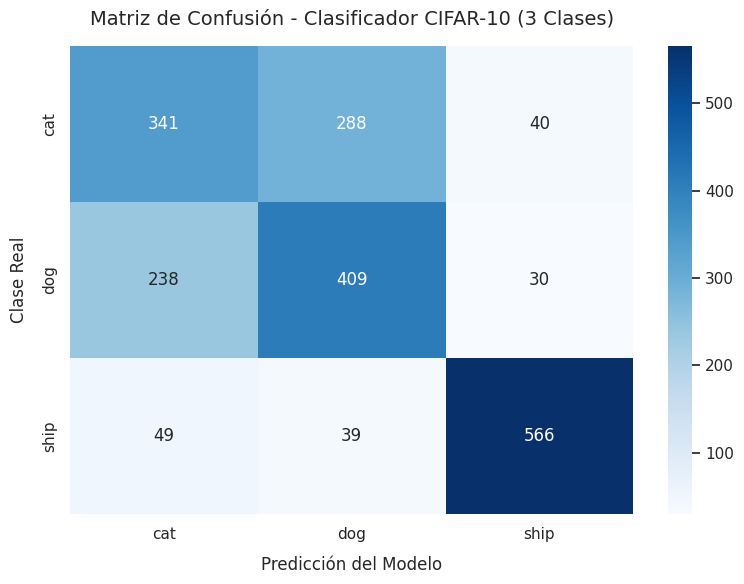

In [ ]:
# Visualizar matriz de confusión

# Nombres de las clases mapeadas para el reporte gráfico
target_names = [class_names[sel_class] for sel_class in selected_classes]

# Generar gráfico de Matriz de Confusión
print("\nVisualizando la matriz de confusión ...")
plt.figure(figsize=(8, 6))
sns.set_theme(style='whitegrid')
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Matriz de Confusión - Clasificador CIFAR-10 (3 Clases)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Clase Real', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### Tarea 4 - Ajuste Hiperparámetros

Buscar una precisión mayor a 0.6 y variar hiperparámetros con la finalidad de
mejorar la precisión

In [ ]:
# Importar liberias de python

import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from datetime import datetime

In [ ]:
# Definir el pipeline base
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=500, tol=1e-3, random_state=42))
])

# Definir el grid de parámetros utilizando una lista de diccionarios
param_combinations = [
    {
        'logreg__solver': ['liblinear'],
        'logreg__C': [0.1, 1, 10],
        'logreg__penalty': ['l1']
    },
    {
        'logreg__solver': ['saga'],
        'logreg__C': [0.1, 1, 10],
        'logreg__penalty': ['l2'],
        'logreg__multi_class': ['multinomial']
    }
]

# ParameterGrid para transformar el diccionario en una lista de experimentos
grid_iter = ParameterGrid(param_combinations)

In [ ]:
# Ejecutar experimentos con ajuste de parámetros

print(f"Iniciando evaluación de {len(grid_iter)} experimentos distintos...\n")

for i, params in enumerate(grid_iter, start=1):
    print("=" * 70)
    print(f" EXPERIMENTO #{i}")
    print("=" * 70)
    print(f"Configuración: {params}\n")

    # Configurar los hiperparámetros dinámicamente en el pipeline
    base_pipe.set_params(**params)

    # Entrenar el modelo con el subconjunto de entrenamiento
    base_pipe.fit(X_train_feat, y_train_sub)

    # Predecir sobre el subconjunto de evaluación
    y_pred = base_pipe.predict(X_test_feat)

    # Reporte de clasificación
    print("Reporte de clasificación:")
    print(classification_report(y_test_sub, y_pred, digits=2))

    # Matriz de confusión
    print("Matriz de confusión:")
    print(confusion_matrix(y_test_sub, y_pred))
    print("\n" + "-" * 70 + "\n")

Iniciando evaluación de 6 experimentos distintos...

 EXPERIMENTO #1
Configuración: {'logreg__C': 0.1, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.58      0.54      0.56       669
           1       0.59      0.61      0.60       677
           2       0.88      0.91      0.89       654

    accuracy                           0.68      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.68      0.68      0.68      2000

Matriz de confusión:
[[361 259  49]
 [229 413  35]
 [ 34  25 595]]

----------------------------------------------------------------------

 EXPERIMENTO #2
Configuración: {'logreg__C': 1, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.53      0.51      0.52       669
           1       0.56      0.59      0.57       677

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.54      0.49      0.52       669
           1       0.56      0.60      0.58       677
           2       0.87      0.88      0.87       654

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000

Matriz de confusión:
[[331 287  51]
 [234 408  35]
 [ 43  36 575]]

----------------------------------------------------------------------

 EXPERIMENTO #5
Configuración: {'logreg__C': 1, 'logreg__multi_class': 'multinomial', 'logreg__penalty': 'l2', 'logreg__solver': 'saga'}



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.54      0.49      0.52       669
           1       0.55      0.60      0.58       677
           2       0.87      0.88      0.87       654

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.65      0.66      0.65      2000

Matriz de confusión:
[[331 288  50]
 [235 405  37]
 [ 42  38 574]]

----------------------------------------------------------------------

 EXPERIMENTO #6
Configuración: {'logreg__C': 10, 'logreg__multi_class': 'multinomial', 'logreg__penalty': 'l2', 'logreg__solver': 'saga'}



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.54      0.49      0.52       669
           1       0.55      0.60      0.58       677
           2       0.87      0.88      0.87       654

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.65      0.66      0.65      2000

Matriz de confusión:
[[331 288  50]
 [235 405  37]
 [ 42  38 574]]

----------------------------------------------------------------------



### Análisis de resultados de experimentos de afinación de hiperparámetros

La siguiente tabla consolida las métricas clave de cada experimento:

| $Exp$ | $\text{Solver}$ | $\text{Regularización}$ | $\text{Penalización}$ | $\text{Accuracy Global }$ | $\text{F1 Score Clase 0 }$ | $\text{F1 Score Clase 1 }$ | $\text{F1 Score Clase 2 }$ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **1** | liblinear | 0.1 | L1 | 0.68 (68%)| 0.56 | 0.60 | 0.89
| **2** | liblinear | 1.0 | L1 | 0.65 (65%)| 0.52 | 0.57 | 0.85
| **3** | liblinear | 10  | L1 | 0.64 (64%)| 0.51 | 0.56 | 0.84
| **4** | saga | 0.1 | L2 | 0.66 (66%)| 0.52 | 0.58 | 0.87
| **5** | saga | 1.0 | L2 | 0.66 (66%)| 0.52 | 0.58 | 0.87
| **6** | saga | 10 | L2 | 0.66 (66%)| 0.52 | 0.58 | 0.87

La configuración más óptima es la del Experimento #1:

* logreg__solver: 'liblinear'
* logreg__C: 0.1
* logreg__penalty: 'l1'

Rendimiento Máximo:
- Es el único experimento que supera la meta original de 0.60 llegando a un 0.68 de Accuracy, superando por un 2% a los experimentos con SAGA y por un 3%-4% a los demás con liblinear.

Mejor F1-Score en todas las clases individuales:
- el Experimento #1 logra los valores más altos de F1-Score para la Clase 0 (0.56), Clase 1 (0.60) y Clase 2 (0.89). No hay un trade-off negativo; es superior de manera uniforme.

Impacto por clase:
- En todos los experimentos, la clase 2 obtiene un excelente rendimiento (F1-score de 0.89 en Exp 1). Al mirar su matriz de confusión, el modelo apenas confunde esta clase con las otras (solo 34 y 25 falsos negativos en Exp 1). Esto indica que las características de color o bordes de la Clase 2 están muy bien separadas linealmente de las otras dos, según lo esperado: Clase 2 (ship) muy diferente a Clase 1 (cat) y Clase 2 (dog)

- El conflicto entre Clase 0 y Clase 1: En el Exp 1, el modelo confunde 259 veces imágenes de la Clase 0 como si fueran de la Clase 1, y 229 veces imágenes de la Clase 1 como la Clase 0. Un clasificador lineal sufre para separarlas ya que comparten características espaciales o densidades de bordes muy similares: Clase 1 (cat) y Clase 2 (dog). Sin embargo, el Exp 1 mitiga este problema mejor que ningún otro (reduciendo estos errores cruzados que en otros experimentos superan los 280).

## Ejercicio 2: Clasificador usando K-Nearest Neighbors

### Descripción

Entrenar un clasificador de imágenes entre 3 tipos de clases usando el algoritmo
K-NN. Para ello escoja 3 clases entre las 10 que ofrece el dataset de CIFAR-10.

In [ ]:
# Importa Liberías

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import tarfile
import pickle
import urllib.request

from sklearn.pipeline import Pipeline
from tensorflow.keras.datasets import cifar10
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Tarea 1 - Carga de Datos y Selección de Clases

Cargar del dataset CIFAR-10 y extraer solo 3 clases para el entrenamiento (use
cifar10.load_data() y use los valores por defecto que devuelve).

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

selected_classes = [3, 5, 8]
target_names = [class_names[i] for i in selected_classes]
class_mapping = {original: new for new, original in enumerate(selected_classes)}

train_mask = np.isin(y_train, selected_classes)
test_mask = np.isin(y_test, selected_classes)

x_train_3 = x_train[train_mask]
y_train_3 = np.array([class_mapping[label] for label in y_train[train_mask]])
x_test_3 = x_test[test_mask]
y_test_3 = np.array([class_mapping[label] for label in y_test[test_mask]])

print("Clases seleccionadas:", target_names)
print("x_train_3:", x_train_3.shape)
print("y_train_3:", y_train_3.shape)
print("x_test_3:", x_test_3.shape)
print("y_test_3:", y_test_3.shape)

### Tarea 2 - Función de Extracción de Características

Crear una función que extraiga 8 características de cada imagen (en este caso
usaremos los canales R,G,B,H,S,V, bordes horizontales de sobel y bordes
verticales de sobel )

In [ ]:
def extract_features(image, sobel_ksize=3):
    """Extrae 8 características globales de una imagen RGB de CIFAR-10."""
    image_rgb = image.astype(np.float32) / 255.0

    r_mean = image_rgb[:, :, 0].mean()
    g_mean = image_rgb[:, :, 1].mean()
    b_mean = image_rgb[:, :, 2].mean()

    image_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float32)
    h_mean = image_hsv[:, :, 0].mean() / 179.0
    s_mean = image_hsv[:, :, 1].mean() / 255.0
    v_mean = image_hsv[:, :, 2].mean() / 255.0

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    sobel_vertical = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    sobel_horizontal = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=sobel_ksize)

    sobel_horizontal_mean = np.mean(np.abs(sobel_horizontal))
    sobel_vertical_mean = np.mean(np.abs(sobel_vertical))

    return np.array([
        r_mean, g_mean, b_mean,
        h_mean, s_mean, v_mean,
        sobel_horizontal_mean, sobel_vertical_mean
    ], dtype=np.float32)


def prepare_feature_matrix(images, sobel_ksize=3):
    return np.array([extract_features(image, sobel_ksize) for image in images], dtype=np.float32)


feature_names = [
    "R", "G", "B", "H", "S", "V",
    "Sobel horizontal", "Sobel vertical"
]


### Tarea 3 - Entrenamiento y Evaluación

Usar las características extraídas para entrenar el modelo de regresión
logística, generar e imprimir un reporte de clasificación y una matriz de
confusión.

#### Preparar Matrices de Características

Se usan todas las imágenes de las 3 clases seleccionadas: 15000 para entrenamiento y 3000 para evaluación.

In [ ]:
X_train = prepare_feature_matrix(x_train_3)
X_test = prepare_feature_matrix(x_test_3)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Características:", feature_names)
print("Primera fila:", X_train[0])

### Tarea 4 - Ajuste Hiperparámetros

Buscar una precisión mayor a 0.6 y variar hiperparámetros con la finalidad de
mejorar la precisión

#### Entrenar KNN y variar hiperparámetros

In [ ]:
knn_results = []
valores_k = [3, 5, 7, 11, 15, 21]
weights_options = ["uniform", "distance"]
metrics = ["euclidean", "manhattan"]

for k in valores_k:
    for weights in weights_options:
        for metric in metrics:
            knn_model = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(
                    n_neighbors=k,
                    weights=weights,
                    metric=metric,
                    n_jobs=-1
                ))
            ])

            knn_model.fit(X_train, y_train_3)
            y_pred_tmp = knn_model.predict(X_test)
            acc_tmp = accuracy_score(y_test_3, y_pred_tmp)
            knn_results.append((k, weights, metric, acc_tmp, knn_model))

knn_results_sorted = sorted(knn_results, key=lambda item: item[3], reverse=True)

print("Mejores resultados KNN")
print("k\tweights\tmetric\t\taccuracy")
for k, weights, metric, acc, _ in knn_results_sorted[:10]:
    print(f"{k}\t{weights}\t{metric}\t{acc:.4f}")

best_k, best_weights, best_metric, best_accuracy, best_knn_model = knn_results_sorted[0]
print(f"\nMejor k: {best_k}")
print(f"Mejor weights: {best_weights}")
print(f"Mejor metric: {best_metric}")
print(f"Mejor accuracy: {best_accuracy:.4f}")


#### Reporte de Clasificación y Matriz de Confusión

In [ ]:
y_pred_knn = best_knn_model.predict(X_test)

print("Reporte de clasificación - KNN")
print(classification_report(y_test_3, y_pred_knn, target_names=target_names))

cm_knn = confusion_matrix(y_test_3, y_pred_knn)
print("Matriz de confusión - KNN:\n", cm_knn)

ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=target_names).plot(
    cmap="Greens",
    values_format="d"
)
plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real")
plt.tight_layout()
plt.show()

if best_accuracy > 0.6:
    print("Se cumple el objetivo: precisión mayor a 0.6")
else:
    print("No se llegó a 0.6; conviene probar más hiperparámetros u otra combinación de clases")

### Tarea 5 - Visualizar Predicciones

Visualizar algunas 15 predicciones al azar.

In [ ]:
rng = np.random.default_rng(42)
indices = rng.choice(len(x_test_3), size=15, replace=False)

plt.figure(figsize=(15, 8))
for pos, idx in enumerate(indices, start=1):
    real = y_test_3[idx]
    pred = y_pred_knn[idx]
    color = "green" if real == pred else "red"

    plt.subplot(3, 5, pos)
    plt.imshow(x_test_3[idx])
    plt.title(
        f"Real: {target_names[real]}\nPred: {target_names[pred]}",
        color=color,
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


### Conclusiones

El clasificador KNN logra separar las clases cat, dog y ship usando las 8 características solicitadas. Al variar k, weights y la métrica de distancia, se selecciona automáticamente la configuración con mejor precisión sobre el conjunto de prueba.